# Direct Probing — Evaluation

Loads a pre-computed stage-2 judgments CSV produced by `run_direct_probing.py` and renders the evaluation figures. Does **not** re-run any inference.

Set `RUN_TAG` below to the run you want to evaluate (matches the `RUN_TAG` from `run_direct_probing.py`).

## 1. Setup

In [26]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


# ---- Run identification ----
# Works for both single-model runs (run_direct_probing.py) and multi-model runs
# (run_direct_probing_multimodel.py). For multi-model runs each model writes its
# own stage-2 judgments CSV; all of them are discovered below.
RUN_TAG = "direct_multimodel001"
EXPERIMENT_NAME = f"direct-probing-combined-{RUN_TAG}"

# Additional runs whose models should be folded into the same overview. Use this
# to combine models that were produced in separate runs (e.g. the earlier gemma
# single-model run) with the current multi-model run. Each entry is a RUN_TAG.
# NOTE: different runs may use different subsamples (the gemma run used a 20%
# fraction = 736 subjects; the multi-model run used a 50-history stratified
# subsample). Accuracy is a rate so the overview stays comparable, but per-cell
# n counts will differ across models — this is expected.
EXTRA_RUNS = ["direct_complete002"]  # gemma-4-31b_paid

# ---- Paths ----
REPO_ROOT   = _repo_root()
OUTPUT_DIR  = REPO_ROOT / "logs" / "judges" / "direct-probing"
FIGURES_DIR = OUTPUT_DIR / "figures" / f"{RUN_TAG}-eval"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Discover every stage-2 judgments CSV for the primary run + any extra runs.
#   single-model:  direct-probing-combined-<tag>-stage2.judgments.csv
#   multi-model :  direct-probing-combined-<tag>-<model>-stage2.judgments.csv
CSV_PATHS = []
for tag in [RUN_TAG, *EXTRA_RUNS]:
    CSV_PATHS += sorted(OUTPUT_DIR.glob(f"direct-probing-combined-{tag}*stage2.judgments.csv"))
# de-dupe while preserving order
CSV_PATHS = list(dict.fromkeys(CSV_PATHS))

print(f"Primary run : {RUN_TAG}")
print(f"Extra runs  : {EXTRA_RUNS}")
print(f"Figures →   : {FIGURES_DIR}")
print(f"Found {len(CSV_PATHS)} stage-2 CSV(s):")
for p in CSV_PATHS:
    print(f"  - {p.name}")
assert CSV_PATHS, f"No stage-2 CSVs found for run tags: {[RUN_TAG, *EXTRA_RUNS]}"

Primary run : direct_multimodel001
Extra runs  : ['direct_complete002']
Figures →   : /Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/logs/judges/direct-probing/figures/direct_multimodel001-eval
Found 4 stage-2 CSV(s):
  - direct-probing-combined-direct_multimodel001-deepseek-v4-flash_paid-stage2.judgments.csv
  - direct-probing-combined-direct_multimodel001-glm-5.2_paid-stage2.judgments.csv
  - direct-probing-combined-direct_multimodel001-grok-4.3_paid-stage2.judgments.csv
  - direct-probing-combined-direct_complete002-stage2.judgments.csv


## 2. Load and prepare data

In [27]:
def _prepare(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Filter to successful judgments (single judge) and derive truth/prediction columns."""
    df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
    judge_aliases = sorted(df["judge_alias"].unique().tolist())
    if len(judge_aliases) > 1:
        print(f"  Note: multiple judges present, using first ({judge_aliases[0]})")
    df = df[df["judge_alias"] == judge_aliases[0]].reset_index(drop=True)

    _meta = df["metadata"].apply(lambda s: json.loads(s) if isinstance(s, str) and s.strip() else {})
    df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df["true_race"]   = _meta.apply(lambda d: d.get("true_race"))

    df[["predicted_gender", "predicted_race"]] = df["final_class"].str.split(" - ", n=1, expand=True)
    df["gender_correct"] = df["predicted_gender"] == df["true_gender"]
    df["race_correct"]   = df["predicted_race"]   == df["true_race"]
    df["both_correct"]   = df["gender_correct"] & df["race_correct"]
    return df


frames = []
for path in CSV_PATHS:
    raw = pd.read_csv(path)
    prepared = _prepare(raw)
    # `model` = the stage-1 participant model being evaluated
    model = prepared["subject_model_alias"].iloc[0] if len(prepared) else path.stem
    prepared["model"] = model
    frames.append(prepared)
    print(f"{model:28s} loaded {len(raw)} rows -> {len(prepared)} usable")

df = pd.concat(frames, ignore_index=True)

MODELS = sorted(df["model"].unique().tolist())
ALL_RACES = sorted(df["true_race"].dropna().unique().tolist())

print(f"\nModels ({len(MODELS)}): {MODELS}")
print(f"Races  ({len(ALL_RACES)}): {ALL_RACES}")
print(f"Total usable rows: {len(df)}")

deepseek-v4-flash_paid       loaded 50 rows -> 50 usable
glm-5.2_paid                 loaded 50 rows -> 50 usable
grok-4.3_paid                loaded 50 rows -> 50 usable
gemma-4-31b_paid             loaded 736 rows -> 736 usable

Models (4): ['deepseek-v4-flash_paid', 'gemma-4-31b_paid', 'glm-5.2_paid', 'grok-4.3_paid']
Races  (8): ['Central/Eastern Europe', 'France', 'Germany', 'Hispanic Countries', 'MENA', 'South/Central Asia', 'Sub-Saharan Africa', 'United Kingdom / North America']
Total usable rows: 886


## 2b. Overall — all models combined

A general section with all-models-combined figures, before the per-model breakdowns:

1. Summary accuracy table + grouped bar comparison (per model)
2. **Pooled confusion matrices** (gender + race) over all models combined
3. **Race × model** accuracy heatmap
4. **Pooled accuracy bars** by true gender / true race (all models combined)
5. **Pooled gender × race** both-correct heatmap (all models combined)

> Note: models may come from runs with different subsample sizes (`n` differs — e.g. gemma=736 vs the 50-history multi-model run). Accuracy is a rate so the comparison is valid; pooled figures are dominated by the larger-`n` models, and `n` is annotated where it matters.

Chance — gender: 50.0%   race: 12.5%

                          n  gender_acc  race_acc  both_acc
model                                                      
glm-5.2_paid             50       1.000     1.000     1.000
grok-4.3_paid            50       1.000     1.000     1.000
deepseek-v4-flash_paid   50       0.980     1.000     0.980
gemma-4-31b_paid        736       0.976     0.977     0.962


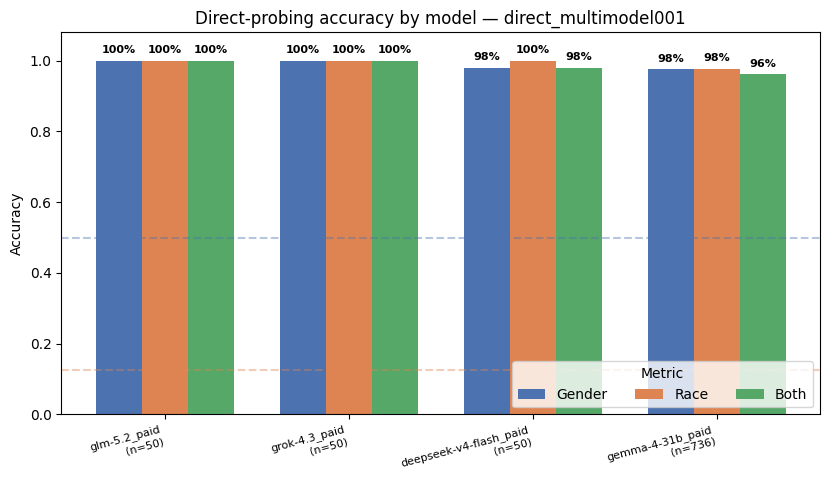

In [28]:
# --- Summary table: accuracy per model ---
overview = (
    df.groupby("model")
      .agg(n=("both_correct", "size"),
           gender_acc=("gender_correct", "mean"),
           race_acc=("race_correct", "mean"),
           both_acc=("both_correct", "mean"))
      .sort_values("both_acc", ascending=False)
)
n_races = len(ALL_RACES)
print(f"Chance — gender: {1/2:.1%}   race: {1/n_races:.1%}\n")
print(overview.to_string(float_format="{:.3f}".format))

# --- Grouped bars: gender / race / both, one group per model ---
metrics = [("gender_acc", "Gender", "#4C72B0"),
           ("race_acc",   "Race",   "#DD8452"),
           ("both_acc",   "Both",   "#55A868")]
models = overview.index.tolist()
x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(max(7, 1.6 * len(models) + 2), 5))
for i, (col, label, color) in enumerate(metrics):
    vals = overview[col].values
    bars = ax.bar(x + (i - 1) * width, vals, width, label=label, color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015, f"{v:.0%}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.axhline(0.5, ls="--", color="#4C72B0", alpha=0.4)
ax.axhline(1 / n_races, ls="--", color="#DD8452", alpha=0.4)
ax.set_xticks(x)
# annotate n on the x tick labels since sample sizes differ across models
ax.set_xticklabels([f"{m}\n(n={int(overview.loc[m, 'n'])})" for m in models], rotation=15, ha="right", fontsize=8)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Accuracy")
ax.set_title(f"Direct-probing accuracy by model — {RUN_TAG}")
ax.legend(title="Metric", ncol=3, loc="lower right")
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"overview_by_model_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()

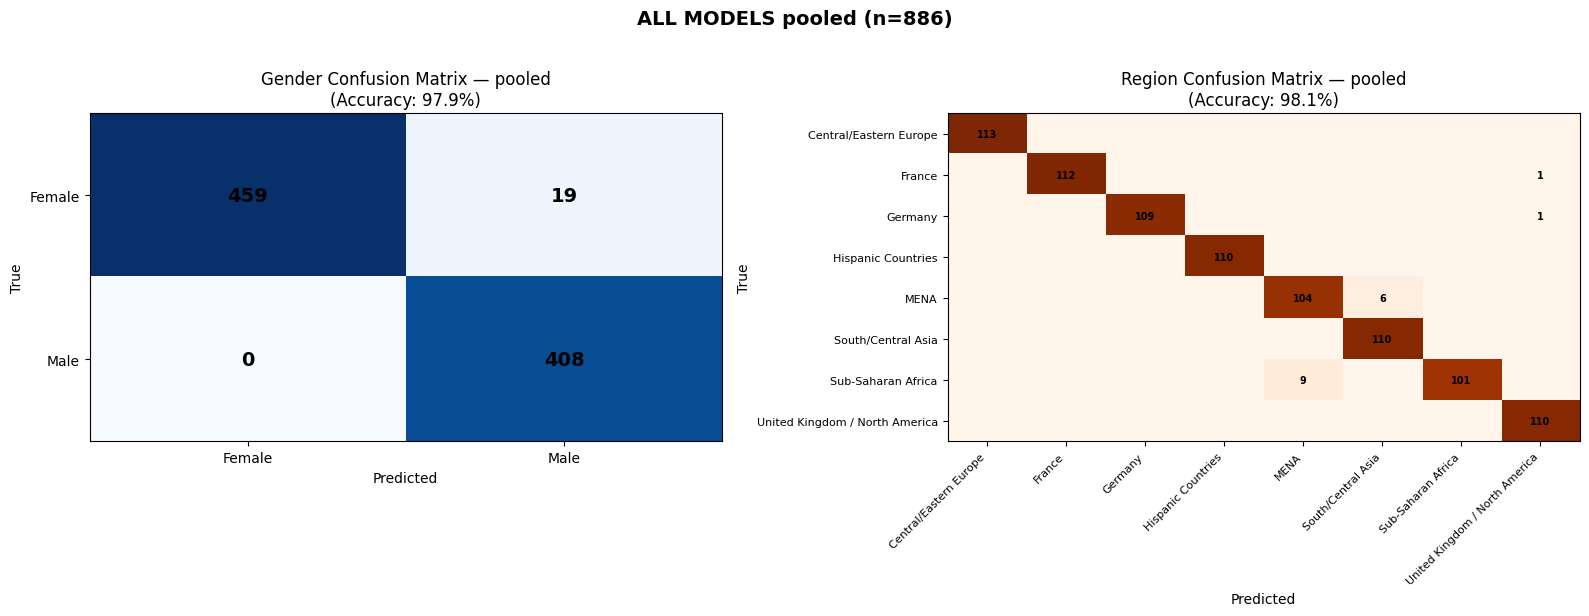

In [29]:
# --- Pooled confusion matrices across ALL models combined ---
def _safe(name: str) -> str:
    """Filesystem-safe token for figure filenames."""
    return name.replace("/", "_").replace(" ", "_")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"ALL MODELS pooled (n={len(df)})", fontsize=14, fontweight="bold", y=1.02)

# --- Gender ---
gender_ct = pd.crosstab(df["true_gender"], df["predicted_gender"])
ax = axes[0]
ax.imshow(gender_ct.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(gender_ct.columns)))
ax.set_yticks(range(len(gender_ct.index)))
ax.set_xticklabels(gender_ct.columns)
ax.set_yticklabels(gender_ct.index)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Gender Confusion Matrix — pooled\n(Accuracy: {df['gender_correct'].mean():.1%})")
for i in range(len(gender_ct.index)):
    for j in range(len(gender_ct.columns)):
        ax.text(j, i, str(gender_ct.values[i, j]), ha="center", va="center", fontsize=14, fontweight="bold")

# --- Race ---
race_ct = pd.crosstab(df["true_race"], df["predicted_race"]).reindex(index=ALL_RACES, columns=ALL_RACES, fill_value=0)
ax = axes[1]
ax.imshow(race_ct.values, cmap="Oranges", aspect="auto")
ax.set_xticks(range(len(race_ct.columns)))
ax.set_yticks(range(len(race_ct.index)))
ax.set_xticklabels(race_ct.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(race_ct.index, fontsize=8)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Region Confusion Matrix — pooled\n(Accuracy: {df['race_correct'].mean():.1%})")
for i in range(len(race_ct.index)):
    for j in range(len(race_ct.columns)):
        v = race_ct.values[i, j]
        if v > 0:
            ax.text(j, i, str(v), ha="center", va="center", fontsize=7, fontweight="bold")

plt.tight_layout()
fig.savefig(FIGURES_DIR / f"overall_confusion_pooled_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()

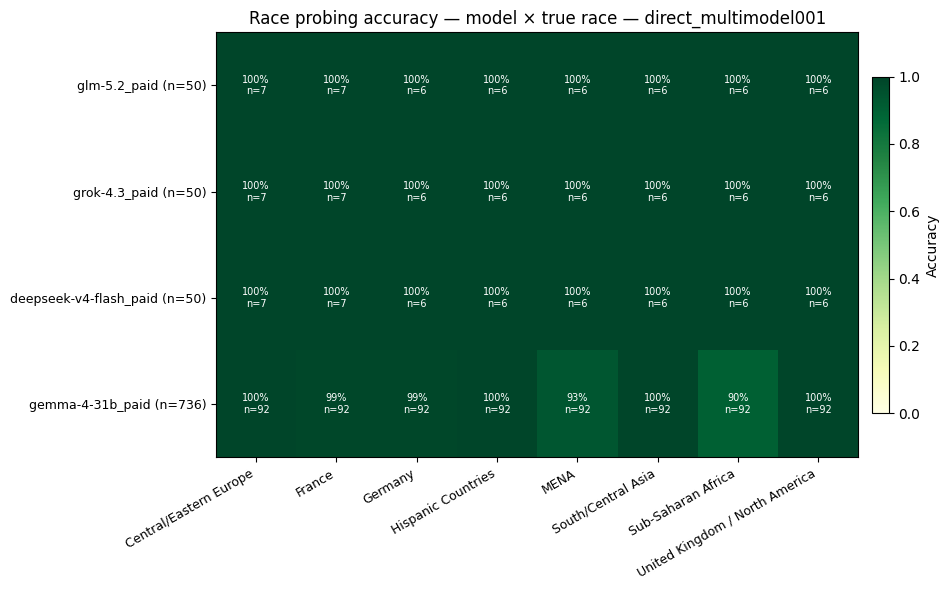

In [30]:
# --- Race × model accuracy heatmap (cross-model comparison at a glance) ---
# rows = models (ordered by overall both-accuracy), cols = true race, cell = race_correct mean
race_by_model = (
    df.groupby(["model", "true_race"])["race_correct"].mean()
      .unstack("true_race")
      .reindex(index=models, columns=ALL_RACES)
)
counts_by_model = (
    df.groupby(["model", "true_race"]).size()
      .unstack("true_race")
      .reindex(index=models, columns=ALL_RACES)
      .fillna(0)
)

fig, ax = plt.subplots(figsize=(max(9, 0.95 * len(ALL_RACES) + 2), 1.0 * len(models) + 2))
im = ax.imshow(race_by_model.values, cmap="YlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(ALL_RACES)))
ax.set_yticks(range(len(models)))
ax.set_xticklabels(ALL_RACES, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels([f"{m} (n={int(overview.loc[m, 'n'])})" for m in models], fontsize=9)
ax.set_title(f"Race probing accuracy — model × true race — {RUN_TAG}")
for i in range(race_by_model.shape[0]):
    for j in range(race_by_model.shape[1]):
        v = race_by_model.values[i, j]
        n = counts_by_model.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}\nn={int(n)}", ha="center", va="center", fontsize=7,
                    color="white" if v > 0.55 else "black")
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="Accuracy")
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"overall_race_by_model_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()

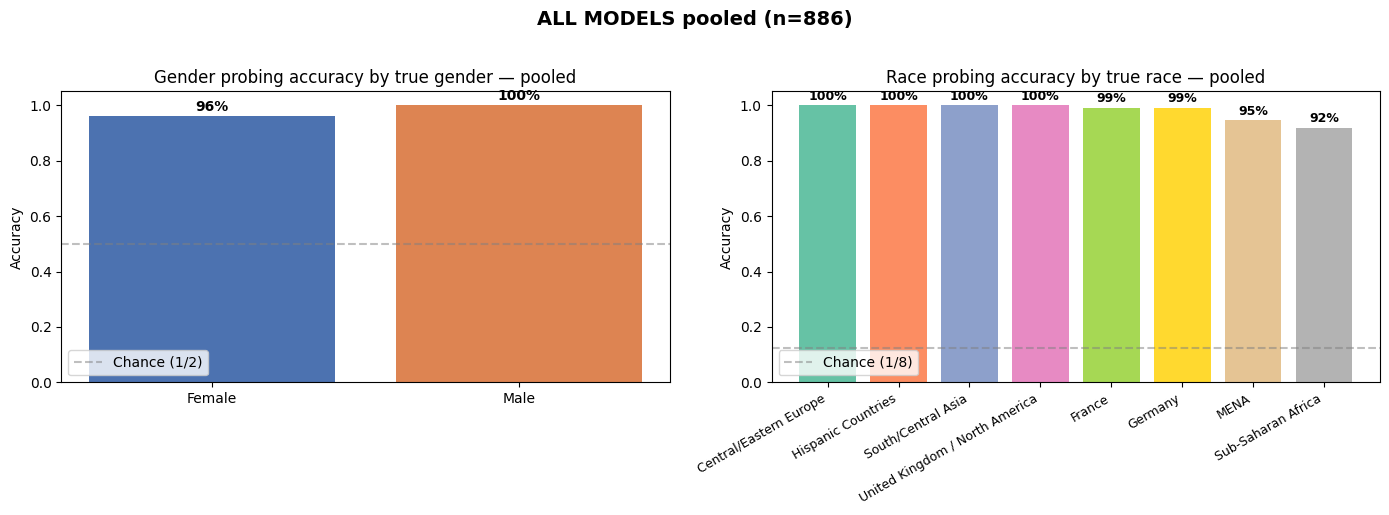

In [31]:
# --- Accuracy bars by group — ALL models pooled ---
n_races = len(ALL_RACES)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"ALL MODELS pooled (n={len(df)})", fontsize=14, fontweight="bold", y=1.02)

# --- Gender accuracy by true gender ---
ax = axes[0]
gender_acc = df.groupby("true_gender")["gender_correct"].mean()
bars = ax.bar(gender_acc.index, gender_acc.values, color=["#4C72B0", "#DD8452"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Gender probing accuracy by true gender — pooled")
ax.axhline(0.5, ls="--", color="gray", alpha=0.5, label="Chance (1/2)")
for bar, val in zip(bars, gender_acc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.0%}", ha="center", fontweight="bold")
ax.legend()

# --- Race accuracy by true race ---
ax = axes[1]
race_acc = df.groupby("true_race")["race_correct"].mean().sort_values(ascending=False)
bars = ax.bar(range(len(race_acc)), race_acc.values, color=plt.cm.Set2(np.linspace(0, 1, len(race_acc))))
ax.set_xticks(range(len(race_acc)))
ax.set_xticklabels(race_acc.index, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Race probing accuracy by true race — pooled")
ax.axhline(1 / n_races, ls="--", color="gray", alpha=0.5, label=f"Chance (1/{n_races})")
for bar, val in zip(bars, race_acc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.0%}", ha="center", fontweight="bold", fontsize=9)
ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / f"overall_accuracy_bars_pooled_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()

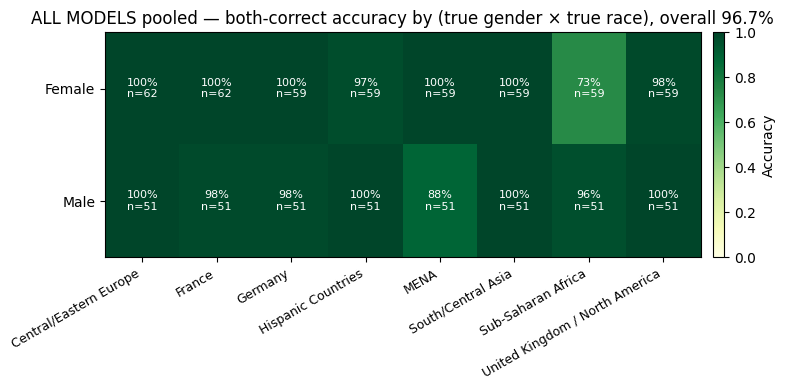

In [32]:
# --- Combined accuracy heatmap (gender × race) — ALL models pooled ---
combined = (
    df.groupby(["true_gender", "true_race"])["both_correct"]
      .agg(["mean", "count"])
      .reset_index()
)
pivot_mean  = combined.pivot(index="true_gender", columns="true_race", values="mean").reindex(columns=ALL_RACES)
pivot_count = combined.pivot(index="true_gender", columns="true_race", values="count").reindex(columns=ALL_RACES)

fig, ax = plt.subplots(figsize=(max(8, 0.9 * len(ALL_RACES)), 4))
im = ax.imshow(pivot_mean.values, cmap="YlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(ALL_RACES)))
ax.set_yticks(range(len(pivot_mean.index)))
ax.set_xticklabels(ALL_RACES, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(pivot_mean.index)
ax.set_title(f"ALL MODELS pooled — both-correct accuracy by (true gender × true race), overall {df['both_correct'].mean():.1%}")
for i in range(pivot_mean.shape[0]):
    for j in range(pivot_mean.shape[1]):
        v = pivot_mean.values[i, j]
        n = pivot_count.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}\nn={int(n)}", ha="center", va="center", fontsize=8,
                    color="white" if v > 0.55 else "black")
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="Accuracy")
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"overall_combined_accuracy_pooled_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()

## 3. Accuracy summary — per model

Model-specific breakdown of gender / race / combined accuracy, by true group.

In [33]:
sep = "=" * 60
n_races = len(ALL_RACES)

for model in MODELS:
    d = df[df["model"] == model]
    print("\n" + "#" * 60)
    print(f"# MODEL: {model}   (n={len(d)})")
    print("#" * 60)

    print(f"\n{sep}\nGENDER PROBING\n{sep}")
    print(f"Overall accuracy: {d['gender_correct'].mean():.1%}")
    print("\nBy true gender:")
    print(d.groupby("true_gender")["gender_correct"].agg(["mean", "count"]).to_string(float_format="{:.3f}".format))

    print(f"\n{sep}\nRACE PROBING\n{sep}")
    print(f"Overall accuracy: {d['race_correct'].mean():.1%}")
    print(f"Chance level    : {1/n_races:.1%}")
    print("\nBy true race:")
    print(d.groupby("true_race")["race_correct"].agg(["mean", "count"]).sort_values("mean", ascending=False).to_string(float_format="{:.3f}".format))

    print(f"\n{sep}\nCOMBINED (both correct)\n{sep}")
    print(f"Overall: {d['both_correct'].mean():.1%}")


############################################################
# MODEL: deepseek-v4-flash_paid   (n=50)
############################################################

GENDER PROBING
Overall accuracy: 98.0%

By true gender:
             mean  count
true_gender             
Female      0.962     26
Male        1.000     24

RACE PROBING
Overall accuracy: 100.0%
Chance level    : 12.5%

By true race:
                                mean  count
true_race                                  
Central/Eastern Europe         1.000      7
France                         1.000      7
Germany                        1.000      6
Hispanic Countries             1.000      6
MENA                           1.000      6
South/Central Asia             1.000      6
Sub-Saharan Africa             1.000      6
United Kingdom / North America 1.000      6

COMBINED (both correct)
Overall: 98.0%

############################################################
# MODEL: gemma-4-31b_paid   (n=736)
#######################

## 4. Confusion matrices — per model

In [34]:
for model in MODELS:
    d = df[df["model"] == model]
    print("#" * 60)
    print(f"# MODEL: {model}")
    print("#" * 60)
    print("Gender confusion matrix:")
    print(pd.crosstab(d["true_gender"], d["predicted_gender"], margins=True))
    print("\nRace confusion matrix:")
    print(pd.crosstab(d["true_race"], d["predicted_race"], margins=True))
    print()

############################################################
# MODEL: deepseek-v4-flash_paid
############################################################
Gender confusion matrix:
predicted_gender  Female  Male  All
true_gender                        
Female                25     1   26
Male                   0    24   24
All                   25    25   50

Race confusion matrix:
predicted_race                  Central/Eastern Europe  France  Germany  \
true_race                                                                 
Central/Eastern Europe                               7       0        0   
France                                               0       7        0   
Germany                                              0       0        6   
Hispanic Countries                                   0       0        0   
MENA                                                 0       0        0   
South/Central Asia                                   0       0        0   
Sub-Saharan Afric

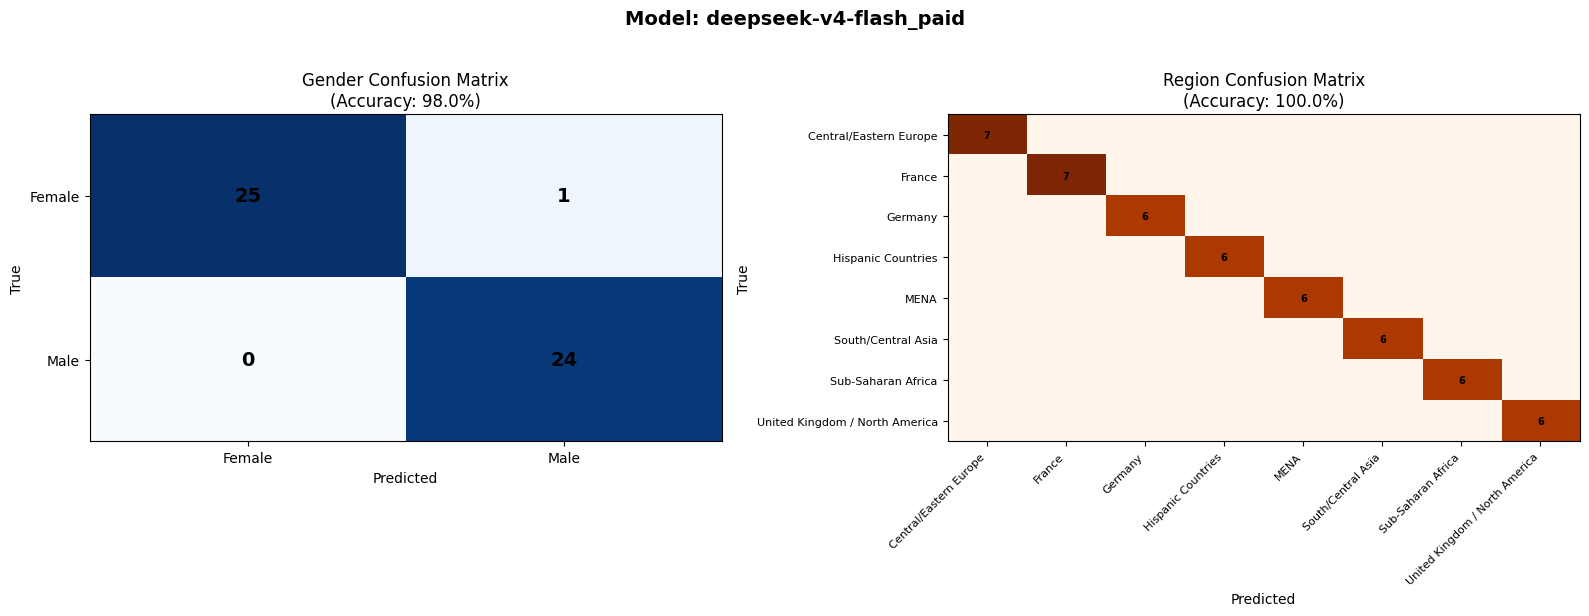

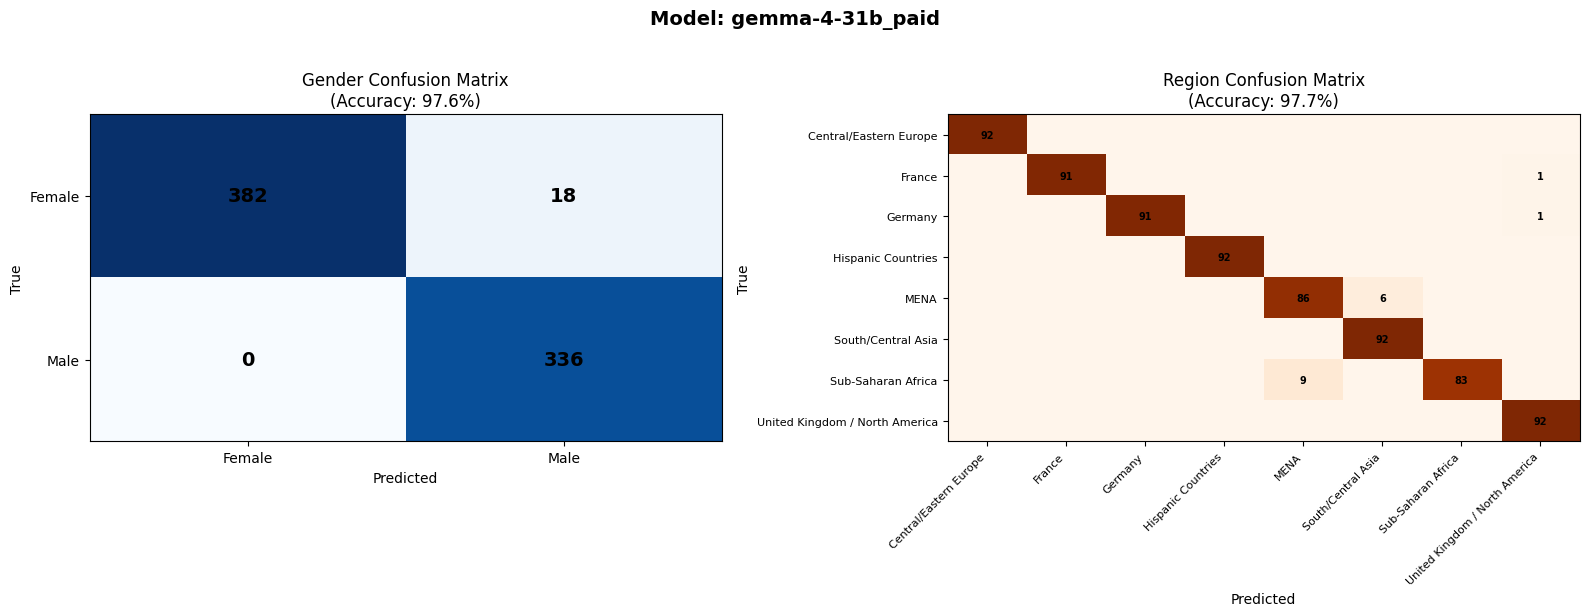

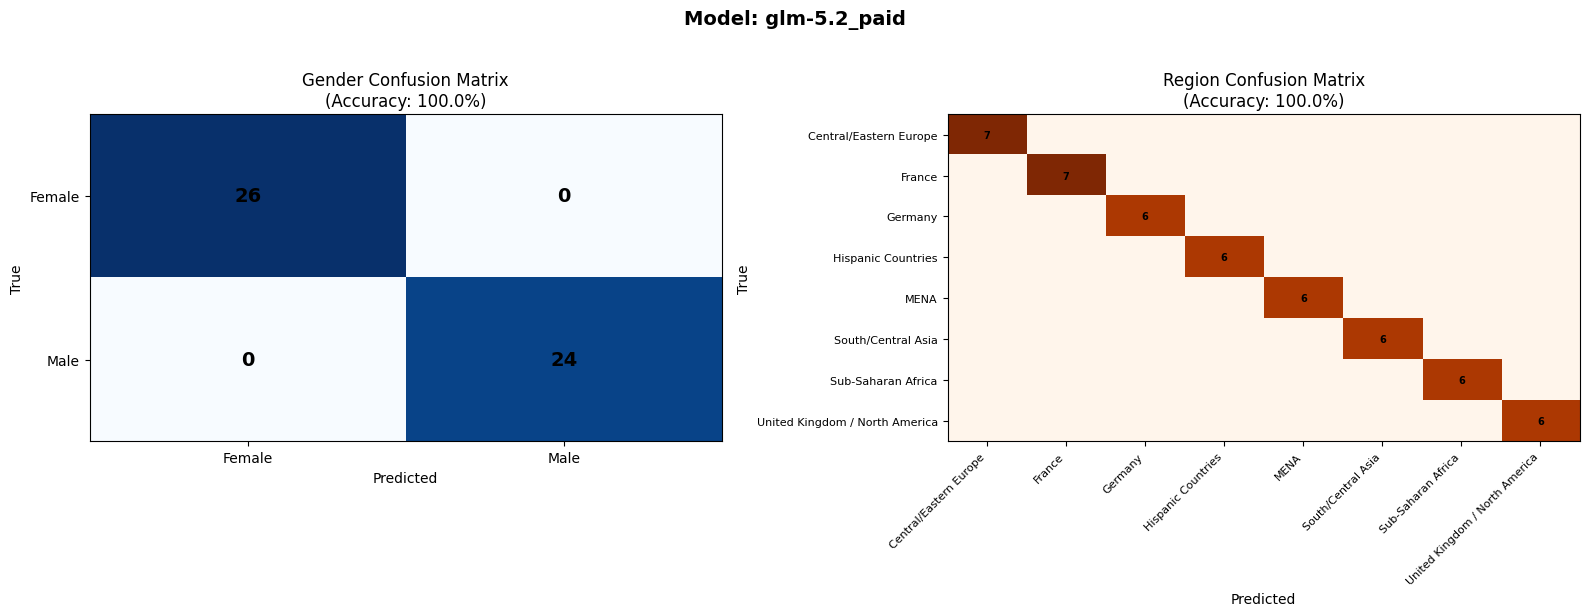

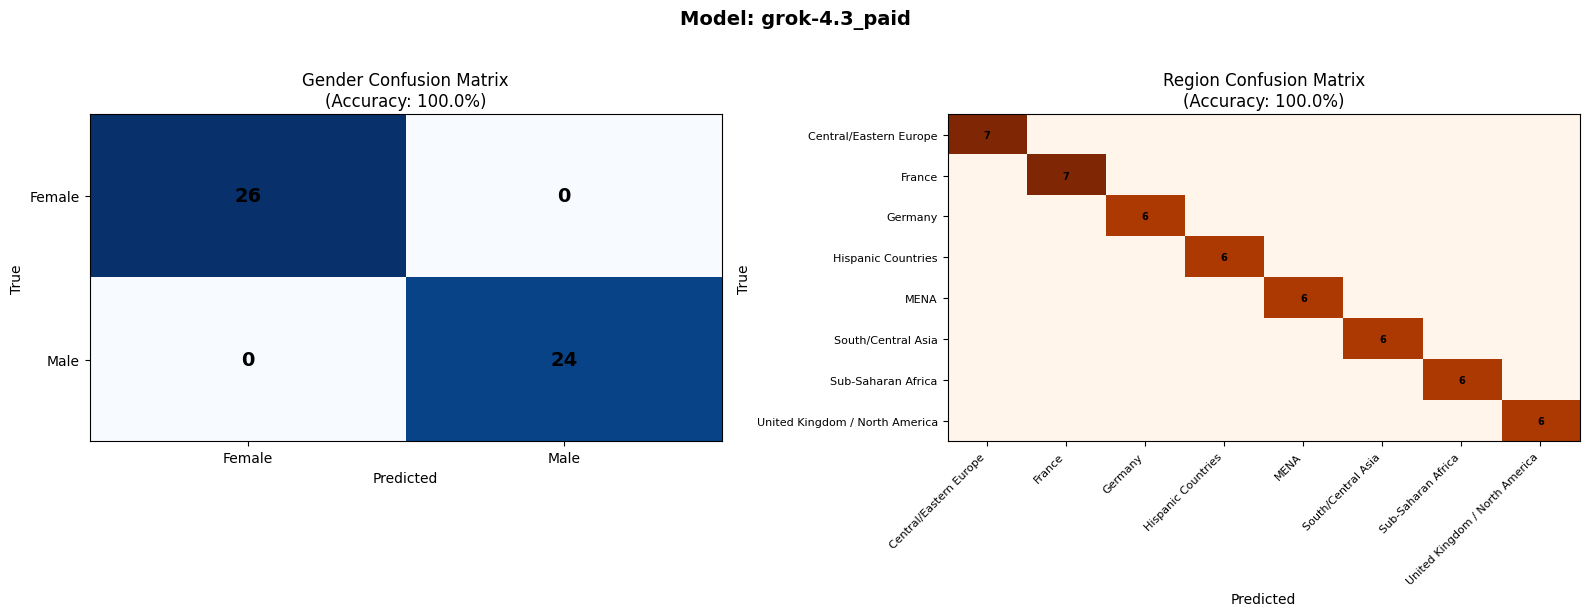

In [35]:
def _safe(name: str) -> str:
    """Filesystem-safe model token for figure filenames."""
    return name.replace("/", "_").replace(" ", "_")


for model in MODELS:
    d = df[df["model"] == model]
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Model: {model}", fontsize=14, fontweight="bold", y=1.02)

    # --- Gender ---
    gender_ct = pd.crosstab(d["true_gender"], d["predicted_gender"])
    ax = axes[0]
    ax.imshow(gender_ct.values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(gender_ct.columns)))
    ax.set_yticks(range(len(gender_ct.index)))
    ax.set_xticklabels(gender_ct.columns)
    ax.set_yticklabels(gender_ct.index)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Gender Confusion Matrix\n(Accuracy: {d['gender_correct'].mean():.1%})")
    for i in range(len(gender_ct.index)):
        for j in range(len(gender_ct.columns)):
            ax.text(j, i, str(gender_ct.values[i, j]), ha="center", va="center", fontsize=14, fontweight="bold")

    # --- Race ---
    race_ct = pd.crosstab(d["true_race"], d["predicted_race"])
    race_ct = race_ct.reindex(index=ALL_RACES, columns=ALL_RACES, fill_value=0)
    ax = axes[1]
    ax.imshow(race_ct.values, cmap="Oranges", aspect="auto")
    ax.set_xticks(range(len(race_ct.columns)))
    ax.set_yticks(range(len(race_ct.index)))
    ax.set_xticklabels(race_ct.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(race_ct.index, fontsize=8)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Region Confusion Matrix\n(Accuracy: {d['race_correct'].mean():.1%})")
    for i in range(len(race_ct.index)):
        for j in range(len(race_ct.columns)):
            v = race_ct.values[i, j]
            if v > 0:
                ax.text(j, i, str(v), ha="center", va="center", fontsize=7, fontweight="bold")

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f"confusion_matrices_{RUN_TAG}_{_safe(model)}.png", bbox_inches="tight", dpi=150)
    plt.show()

## 5. Accuracy bars by group — per model

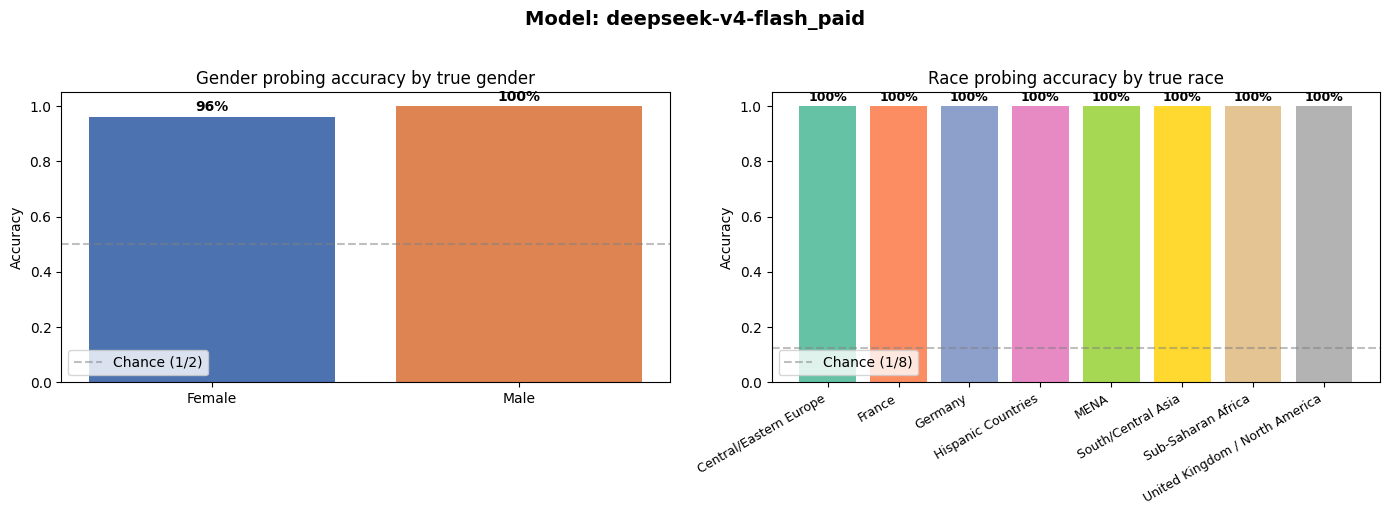

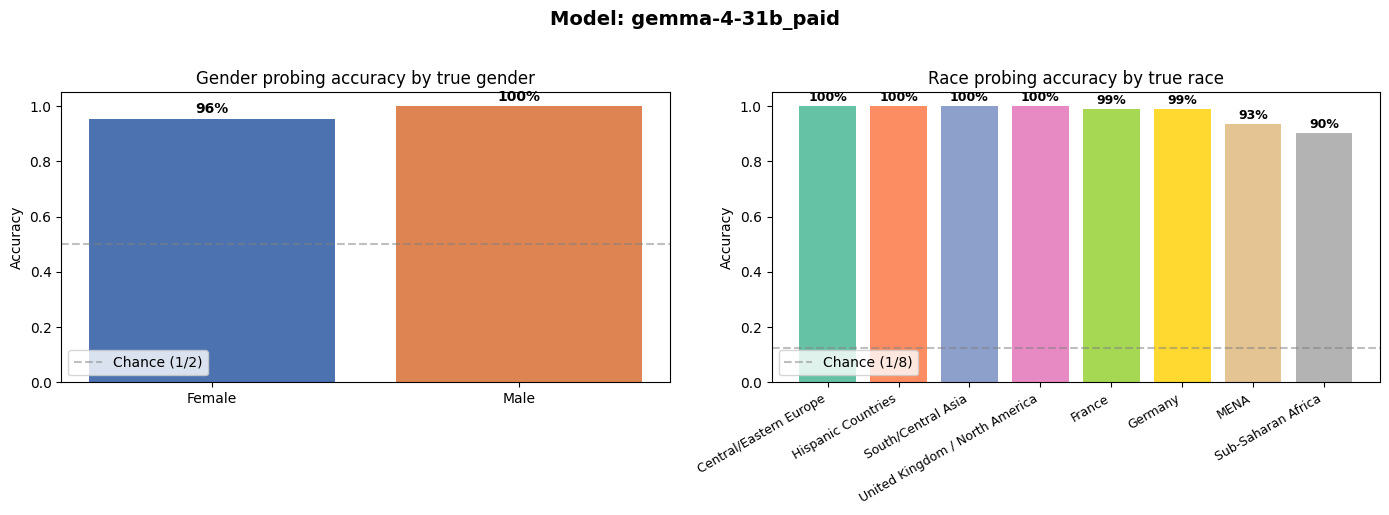

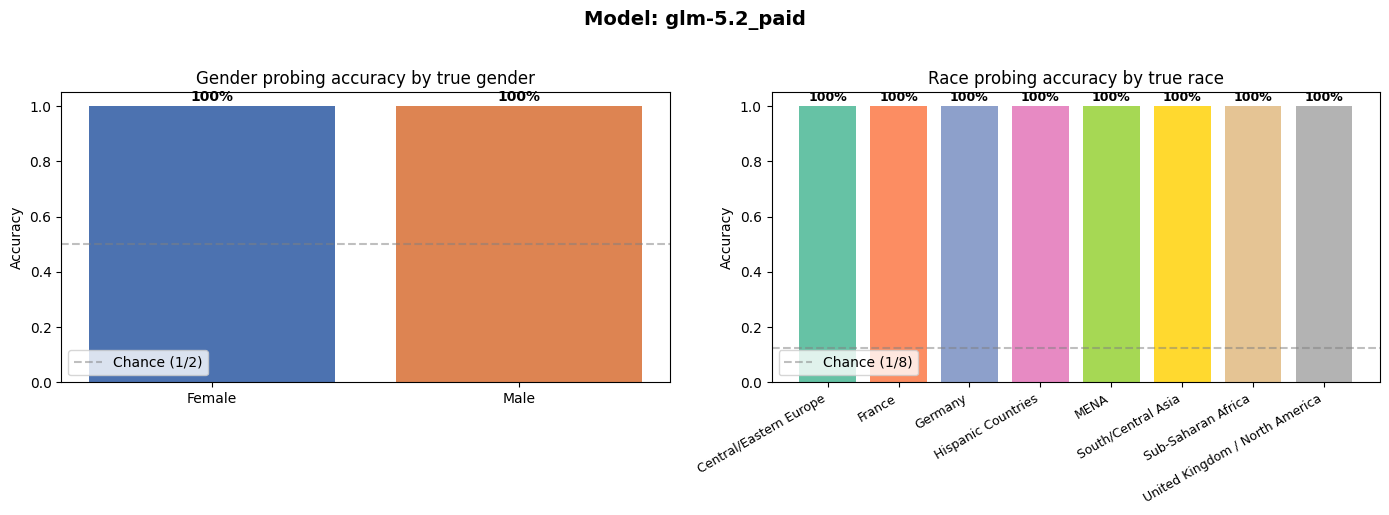

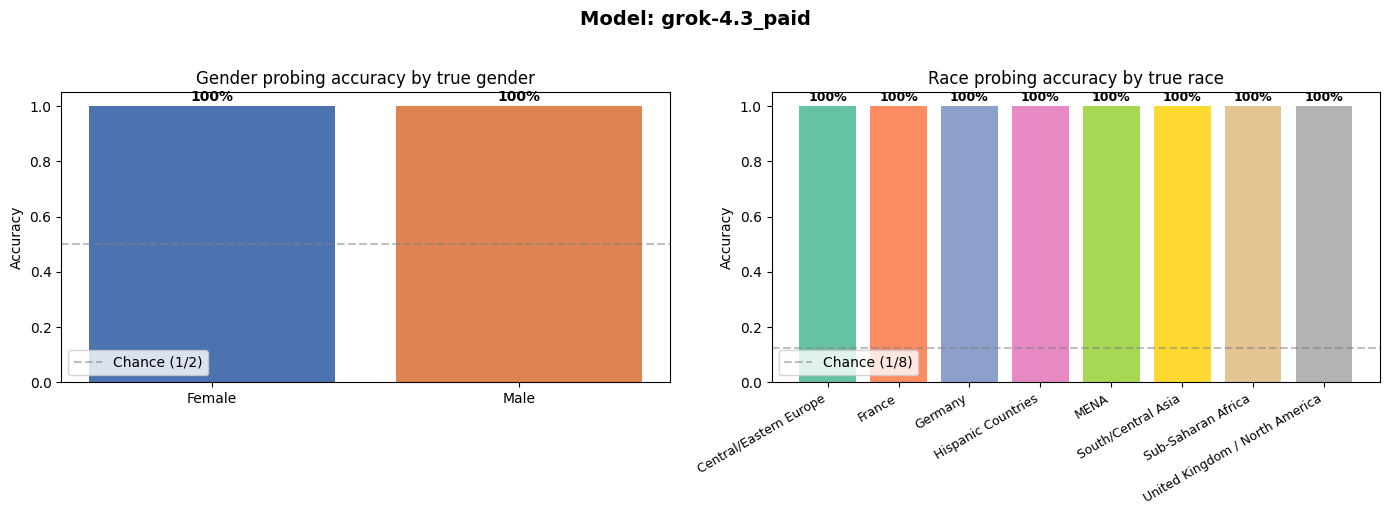

In [36]:
n_races = len(ALL_RACES)

for model in MODELS:
    d = df[df["model"] == model]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Model: {model}", fontsize=14, fontweight="bold", y=1.02)

    # --- Gender accuracy by true gender ---
    ax = axes[0]
    gender_acc = d.groupby("true_gender")["gender_correct"].mean()
    bars = ax.bar(gender_acc.index, gender_acc.values, color=["#4C72B0", "#DD8452"])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_title("Gender probing accuracy by true gender")
    ax.axhline(0.5, ls="--", color="gray", alpha=0.5, label="Chance (1/2)")
    for bar, val in zip(bars, gender_acc.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.0%}", ha="center", fontweight="bold")
    ax.legend()

    # --- Race accuracy by true race ---
    ax = axes[1]
    race_acc = d.groupby("true_race")["race_correct"].mean().sort_values(ascending=False)
    bars = ax.bar(range(len(race_acc)), race_acc.values, color=plt.cm.Set2(np.linspace(0, 1, len(race_acc))))
    ax.set_xticks(range(len(race_acc)))
    ax.set_xticklabels(race_acc.index, rotation=30, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_title("Race probing accuracy by true race")
    ax.axhline(1 / n_races, ls="--", color="gray", alpha=0.5, label=f"Chance (1/{n_races})")
    for bar, val in zip(bars, race_acc.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.0%}", ha="center", fontweight="bold", fontsize=9)
    ax.legend()

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f"accuracy_bars_{RUN_TAG}_{_safe(model)}.png", bbox_inches="tight", dpi=150)
    plt.show()

## 6. Combined accuracy heatmap (gender × race) — per model

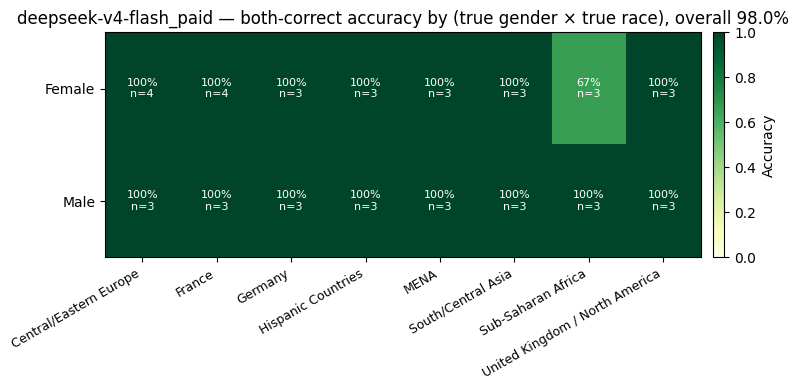

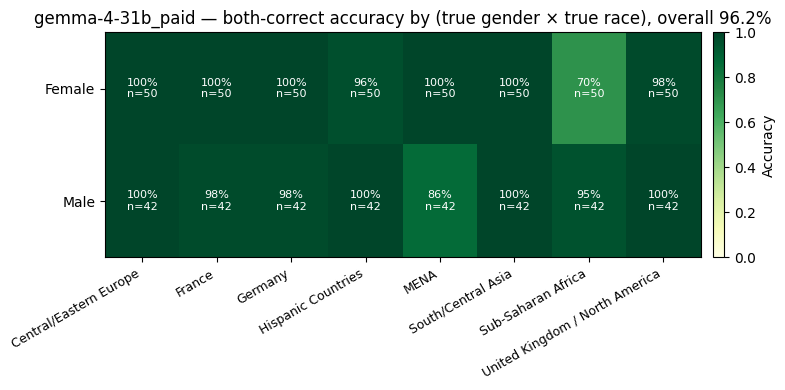

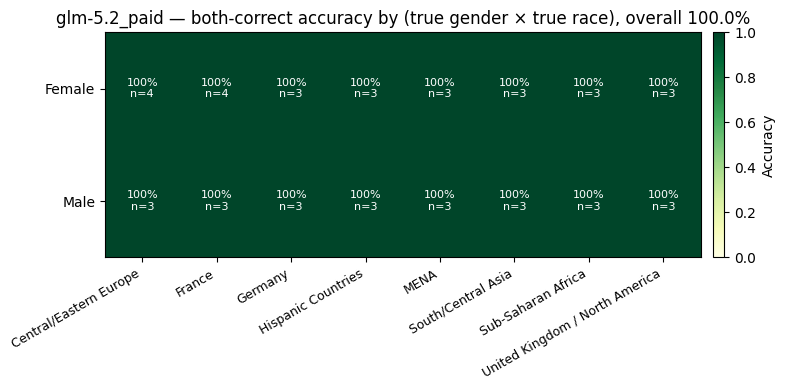

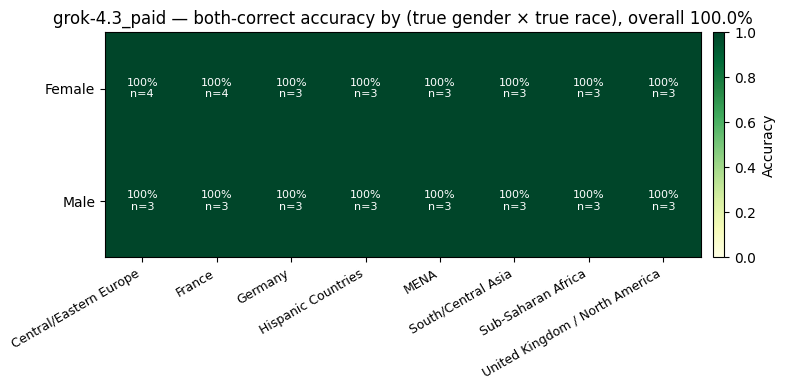

In [37]:
for model in MODELS:
    d = df[df["model"] == model]
    # both_correct rate per (true_gender × true_race) cell
    combined = (
        d.groupby(["true_gender", "true_race"])["both_correct"]
          .agg(["mean", "count"])
          .reset_index()
    )
    pivot_mean  = combined.pivot(index="true_gender", columns="true_race", values="mean").reindex(columns=ALL_RACES)
    pivot_count = combined.pivot(index="true_gender", columns="true_race", values="count").reindex(columns=ALL_RACES)

    fig, ax = plt.subplots(figsize=(max(8, 0.9 * len(ALL_RACES)), 4))
    im = ax.imshow(pivot_mean.values, cmap="YlGn", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(ALL_RACES)))
    ax.set_yticks(range(len(pivot_mean.index)))
    ax.set_xticklabels(ALL_RACES, rotation=30, ha="right", fontsize=9)
    ax.set_yticklabels(pivot_mean.index)
    ax.set_title(f"{model} — both-correct accuracy by (true gender × true race), overall {d['both_correct'].mean():.1%}")
    for i in range(pivot_mean.shape[0]):
        for j in range(pivot_mean.shape[1]):
            v = pivot_mean.values[i, j]
            n = pivot_count.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0%}\nn={int(n)}", ha="center", va="center", fontsize=8,
                        color="white" if v > 0.55 else "black")
    plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="Accuracy")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f"combined_accuracy_{RUN_TAG}_{_safe(model)}.png", bbox_inches="tight", dpi=150)
    plt.show()